# Tuning variance elements for the V-BReE framework
The intent of this notebook is to systematically tune the variance threshold and variance scaling factor for the V-BReE framework.  That tuned value will then be included in the Github repository.

The approach to tuning will be to set the initial variance threshold (5 -> 2) and variance scaling factor (1.4 -> 1.1) and process a sample of 100 (note - limited to 62 due to processing time limits) prompts using the V-BReE framework.  These low results will be used to ensure the framwork does not stop before the best possible degree of consensus is reached.

The results will be analyzed to determine the ideal scaling factor and initial variance threshold by looking at the distribution of the consensus variances over iterations, examining the natural scaling over time of the consensus variances, and identifying potential clustering points of consensus variance convergence.

---

Results:

- Starting threshold: 9.5
- Scaling rate: 1.1

Based on analysis of variance threshold growth rates, characterstics of over-iterated (overshot) responses, and correctness rates, we've determined that the ideal approach to variance scaling is one that starts moderately high, and scales slowly from there.  The high start ensures that it will soon make large strides per iteration, and the low increase rate ensures it starts slow enough to allow for collaboration.  Using a starting threshold of 9.5 and a scaling factor of 1.1 will reach key thresholds:

- 20 variance in 3 cycles
- 50 variance (mean variance across tests) in 6 cycles
- 100 variance (mean variance + 1 standard deviation) in 8 cycles
- max variance in 14 cycles.



## 1. Adding the V-BReE framework to a workspace

### Import the V-BReE module from Github
To install the V-BReE module, clone the git repository into the colab file system.

---

*If you run into problems with folder naming, you should be able to delete or rename the existing folder and then create a fresh clone*

In [ ]:
from pathlib import Path

vbree_path = Path("v_bree.py")

if not vbree_path.is_file():
  !wget https://raw.githubusercontent.com/JasonIves/V-BReE/main/v_bree.py

### Import the module

You can now import the *v_bree* module.

In [ ]:
import v_bree

## 2. Configuring the V-BReE framework workspace

### Store inference connection API key
Modeling and inference connections often require an API key.  That key can be stored in the "Secrets" section of the sidebar, given a name, and then referenced using the *userdata* library.  This example represents a HuggingFace Inference Client key, but other services should work similarly.

Do not store API keys directly in code.

Once the token is stored you will need to give the notebook permission to access it.

In [ ]:
from google.colab import userdata

hfToken = userdata.get('HF_TOKEN')

### Define inference connection client

Define a client connection that uses the OpenAI API format.  Primary testing for this module was done using the [Hugging Face Inference Client](https://huggingface.co/docs/huggingface_hub/en/package_reference/inference_client), but other clients utilizing the OpenAI API format should work as well.


In [ ]:
from huggingface_hub import InferenceClient

client = InferenceClient(
              provider = "auto",
              api_key = hfToken
          )

### General system configuration

As usual, finishing outfitting the workspace with the necessary Python tools.


In [ ]:
import json
import re

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy

### Load data

Load the desired dataset, either from local storage, Google Drive, or a 3rd party download.  In this example the MMLU-PRO dataset will be downloaded from Hugging Face, and converted to a Pandas dataframe.

A sample will be drawn from the dataset, representing 100 total cases across all categories.

In [ ]:
dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test")
data = dataset.to_pandas()

n_cases = 100

##CALCULATE THE RATIO TO PULL FROM EACH CATEGORY
ratio = n_cases / len(data)

##SAMPLE THE APPROPRIATE % OF CASES FROM EACH CATEGORY, FOR A TOTAL OF 100
sample = data.groupby('category').sample(frac = ratio, random_state = 99)

display(sample)

,question_id,question,options,answer,answer_index,cot_content,category,src
3086,3206,The geneticist Mary Lyon hypothesized the exis...,"[In the early female embryo, one copy of the X...",B,1,,biology,ori_mmlu-high_school_biology
2935,3053,All of the following are examples of events th...,[the potential mates experience geographic iso...,D,3,,biology,ori_mmlu-high_school_biology
3355,3476,What prevents the stomach from being digested ...,[The stomach has a high permeability to hydrog...,H,7,,biology,stemez-Biology
3147,3268,Which of the following is an example of a cline?,[Males of some species have long antlers to fi...,H,7,,biology,ori_mmlu-high_school_biology
2883,3001,Which of the following is a correct statement ...,[Living cells of the phloem provide the main c...,H,7,,biology,ori_mmlu-college_biology
...,...,...,...,...,...,...,...,...
1964,2063,After World War II there was much speculation ...,[Only those with a high level of education and...,G,6,,psychology,stemez-Psychology
2074,2174,"According to Abraham Maslow, esteem needs must...","[self-actualization needs, spiritual needs, se...",A,0,,psychology,ori_mmlu-high_school_psychology
2044,2144,The reticular formation and reticular activati...,"[Alertness, Sensation of taste, Hunger and thi...",D,3,,psychology,ori_mmlu-professional_psychology
2577,2686,What are the characteristics of a good manipul...,[1. Overwhelming compassion for others. 2. Unq...,C,2,,psychology,stemez-Psychology


### Configure the data for V-BReE compatibility

A V-BReE compatibile dataset has 4 key components.  Each must be provided, although the domain can be set to a dummy value without impacting ensemble processing.

- An identifier that is unique for each row. Ex: "*12893*"
- The question being asked of the ensemble.  This should be a string. Ex: "*What is 2 + 2?*"
- The possible choices, formatted as a list. Ex: "*[3, 4, 5]*"
  - Actual choices are not required. But an empty list, Ex: "*[]*", should still be submitted in the designated choices column.  When detected the ensemble will proceed in free-response mode instead of MCQ mode.
- Question domain.  Not required. For conveyence to results data. Ex: "*math*"

Any other data submitted to the V-BReE ensemble will be ignored.

In [ ]:
##REFORMAT OPTIONS COLUMN TO ENSURE LIST STRUCTURE
choice_pattern = re.compile(r"\'(.*?)\'")

sample["options"] = sample["options"].astype(str)
sample["options"] = sample["options"].apply(lambda x: re.findall(choice_pattern, x) if pd.notnull(x) else [])

display(sample)

,question_id,question,options,answer,answer_index,cot_content,category,src
3086,3206,The geneticist Mary Lyon hypothesized the exis...,"[In the early female embryo, one copy of the X...",B,1,,biology,ori_mmlu-high_school_biology
2935,3053,All of the following are examples of events th...,[the potential mates experience geographic iso...,D,3,,biology,ori_mmlu-high_school_biology
3355,3476,What prevents the stomach from being digested ...,[The stomach has a high permeability to hydrog...,H,7,,biology,stemez-Biology
3147,3268,Which of the following is an example of a cline?,[Males of some species have long antlers to fi...,H,7,,biology,ori_mmlu-high_school_biology
2883,3001,Which of the following is a correct statement ...,[Living cells of the phloem provide the main c...,H,7,,biology,ori_mmlu-college_biology
...,...,...,...,...,...,...,...,...
1964,2063,After World War II there was much speculation ...,[Only those with a high level of education and...,G,6,,psychology,stemez-Psychology
2074,2174,"According to Abraham Maslow, esteem needs must...","[self-actualization needs, spiritual needs, se...",A,0,,psychology,ori_mmlu-high_school_psychology
2044,2144,The reticular formation and reticular activati...,"[Alertness, Sensation of taste, Hunger and thi...",D,3,,psychology,ori_mmlu-professional_psychology
2577,2686,What are the characteristics of a good manipul...,[1. Overwhelming compassion for others. 2. Unq...,C,2,,psychology,stemez-Psychology


### Instantiate Ensemble class

Create an instance of the Ensemble class, this will be the workflow manager for the V-BReE framework.

Parameters:
- *client* - Object. API inference client
- *response_type* - String, *"logic"* or *"choice"*.  Define the type of response you want from the models.  *"logic"* will return logic only, *"choice"* will return both choice and logic.
- *verbose* - Boolean, default *False*. Control display of status messages.

In [ ]:
e = v_bree.Ensemble(client = client, response_type = "choice", verbose = True)

## 3. Update the variance related framework parameters

Review and then update the variance threshold and variance scaling factor for the framework object.

In [ ]:
print("Pre update")
display(e.get_variance_threshold())
display(e.get_variance_scaling_factor())

e.set_variance_threshold(threshold = 2.0)
e.set_variance_scaling_factor(scaling_factor = 1.1)

print("Post update")
display(e.get_variance_threshold())
display(e.get_variance_scaling_factor())

Pre update


5.0

1.4

Post update


2.0

1.1

### Add models to Ensemble

Add a string refrence for each model you want to inclue in the ensemble.  The format of these strings may vary depending on the client, and you may need to pre-load the models to your workspace if you are using them locally.

Pre-loading is not necessary for Hugging Face Inference Client.

There is no set limit to the number of models that can be added.  Prompting a single model configuration will return non-ensemble, single-prompt results.

In [ ]:
e.add_model("openai/gpt-oss-20b")
e.add_model("Qwen/Qwen2.5-7B-Instruct")
e.add_model("deepseek-ai/DeepSeek-R1-Distill-Llama-8B")
# e.add_model("google/gemma-2-9b-it")
# e.add_model("meta-llama/Llama-3.1-8B-Instruct")

## 4. Acquire V-BReE variance data for analysis
This can be done by running the ensemble (Option A) or downloading the existing data (Option B)

### Option A. Run the V-BReE ensemble

#### Ensemble run

To run the ensemble, pass:
- *data* - DataFrame. Properly formatted data frame.
- *id_col* - String. Column name of the unique identifier column.
- *question_col* - String. Column name of the question text column.
- *choices_col* - String. Column name of the list-formatted choices column.
- *domain_col* - String. Column name of the question domain column.
- *model_algorithm* - String, default *"order_added"*, *"order_added"* or *"random_start"*. Flag for whether the ensemble should always start with the first model added, or start with a random model.
- *temperature* - Float, default *0.0*. Desired temperature that the models should process at.

In [ ]:
##DATA CAPTURE NOW COMPLETE.  IMPORT DATA FROM CSV IN CELL 4.2.
# e.run(data = sample,
#       id_col = "question_id",
#       question_col = "question",
#       choices_col = "options",
#       domain_col = "category",
#       model_algorithm = "random_start",
#       temperature = 0.0)

#### Retrieve the results from the ensemble and save the generated data to csv file.

- *selected_only* - Boolean. Flag indicating if you want the selected responses returned, or all responses processed by the ensemble.

In [ ]:
##DATA CAPTURE NOW COMPLETE.  IMPORT DATA FROM CSV IN CELL 4.2.
# results = e.get_results(selected_only = False)

# results.to_csv("results.csv", index = False)

### Option B. Download the existing data from github

If the data has already been created and saved to file, it can simply be downloaded from github, and loaded for further analysis.

#### Download the data

In [ ]:
from pathlib import Path

var_data_path = Path("variance_tuning_results_20260227.csv")

if not var_data_path.is_file():
  !wget https://raw.githubusercontent.com/JasonIves/V-BReE/main/data/variance_tuning_results_20260227.csv

#### Load the V-BReE variance data from csv

In [ ]:
results = pd.read_csv("variance_tuning_results_20260227.csv")

### Clean the response data

When the best choices were identified, an offset in the code was allowing the 2nd response to be selected, based on the variance between the first two responses.

This has been updated in the V-BReE code, and this section re-calculates the response selection based on those updates.

In [ ]:
##REMOVE VARIANCE AND MOVING AVERAGE VALUES FOR 2ND RESPONSES
results = results.copy()
mod_var = results["score_moving_variance"]
mod_avg = results["score_moving_avg"]

mod_var[results["iteration"] == 1] = numpy.nan
mod_avg[results["iteration"] == 1] = numpy.nan

results["score_moving_variance"] = mod_var
results["score_moving_avg"] = mod_avg


##RESET CHOSEN RESPONSE
results["chosen_response"] = False

##RECALCULATE CHOSEN RESPONSE
ids = results["id"].unique()
for id in ids:
  id_results = results[results["id"] == id]
  sorted_results = id_results.sort_values(
            by=['score_moving_variance', 'score_moving_avg', 'score', 'iteration'],
            ascending=[True, False, False, True])
  selected_result = sorted_results.iloc[0]["iteration"]
  ##DROP RESULTS WHERE VARIANCE CALCULATION OFFSET RESULTED IN EARLY TERMINATION - ASSUMING THESE LOW CYCLE CASES WILL BE COVERED IN CALIBRAION OF HIGHER CYCLE ENTRIES
  if selected_result == 0:
    results.drop(results[results["id"] == id].index, inplace = True)
  else:
    results.loc[(results["id"] == id) & (results["iteration"] == selected_result), "chosen_response"] = True


# results.to_csv("result_adjustment_20260227.csv", index = False)

/tmp/ipython-input-947/1449777988.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_var[results["iteration"] == 1] = numpy.nan
/tmp/ipython-input-947/1449777988.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_avg[results["iteration"] == 1] = numpy.nan


## 5. Exploratory Analysis

### Merge the correct answers with the results

In [ ]:
merged = pd.merge(results, sample[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")
display(merged.head(5))

,id,iteration,model,question,choices,domain,prompt_tokens,previous_answer,updated_answer,selected_choice,response_tokens,scoring_model,score,score_moving_avg,score_moving_variance,chosen_response,confidence_score,question_id,answer
0,3206,0,Qwen/Qwen2.5-7B-Instruct,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,258,NaN,The statement that is NOT correct about Barr b...,C,85,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,100.0,NaN,NaN,False,NaN,3206,B
1,3206,1,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,293,The statement that is NOT correct about Barr b...,The statement that is NOT correct about Barr b...,B,878,openai/gpt-oss-20b,90.0,NaN,NaN,False,1.254777,3206,B
2,3206,2,openai/gpt-oss-20b,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,466,The statement that is NOT correct about Barr b...,The incorrect statement is B. In normal female...,B,420,Qwen/Qwen2.5-7B-Instruct,65.0,85.0,325.0,False,0.147080,3206,B
3,3206,3,Qwen/Qwen2.5-7B-Instruct,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,296,The incorrect statement is B. In normal female...,The incorrect statement is B. In normal female...,B,59,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,100.0,85.0,325.0,False,0.127820,3206,B
4,3206,4,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,The geneticist Mary Lyon hypothesized the exis...,"['In the early female embryo, one copy of the ...",biology,267,The incorrect statement is B. In normal female...,The incorrect statement is B. In normal female...,B,516,openai/gpt-oss-20b,90.0,85.0,325.0,False,0.114598,3206,B


### Assess error rate by model

---

deepseek-ai/DeepSeek-R1-Distill-Llama-8B has a response error rate of over 18%.  Will look for a replacement model.

In [ ]:
##TOTAL NUMBER OF RESPONSES BY MODEL
total_responses = pd.DataFrame(merged.groupby("model")["model"].count())
display(total_responses)

##GROUP BY MODEL AND COUNT NUMBER OF ERROR RESPONSES
error_responses = pd.DataFrame(merged[merged["updated_answer"] == "Error"].groupby("model")["updated_answer"].count())
display(error_responses)

##ERROR RATES:
print("Error Rates:")
print(error_responses["updated_answer"] / total_responses["model"])


,model
model,
Qwen/Qwen2.5-7B-Instruct,1082
deepseek-ai/DeepSeek-R1-Distill-Llama-8B,1082
openai/gpt-oss-20b,1088


,updated_answer
model,
Qwen/Qwen2.5-7B-Instruct,13
deepseek-ai/DeepSeek-R1-Distill-Llama-8B,196
openai/gpt-oss-20b,19


Error Rates:
model
Qwen/Qwen2.5-7B-Instruct                    0.012015
deepseek-ai/DeepSeek-R1-Distill-Llama-8B    0.181146
openai/gpt-oss-20b                          0.017463
dtype: float64


### Review median variance by iteration

Median variance per iteration holds steady, meaning there is no overarching pattern in consensus reaching.

,score_moving_variance
iteration,
0,NaN
1,NaN
2,307.333333
3,191.666667
4,133.333333
...,...
72,2533.333333
73,1200.000000
74,2720.833333


[]

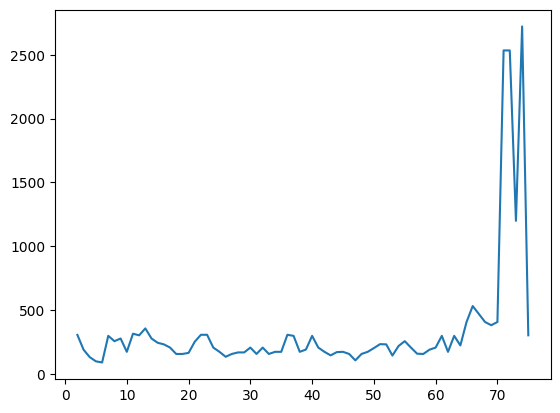

In [ ]:
##MEAN VARIANCE AT EACH ITERATION
median_variance_per_iteration = pd.DataFrame(merged.groupby("iteration")["score_moving_variance"].median())
display(median_variance_per_iteration)

##PLOT MEAN VARIANCE PER ITERATION
plt.plot(median_variance_per_iteration)
plt.plot()

### Number of iterations for selected choice

---

The high number of 1st loop response selections indicates early consensus is common.  This suggests a higher initial threshold should be used to allow "easy" cases to be finished quickly.

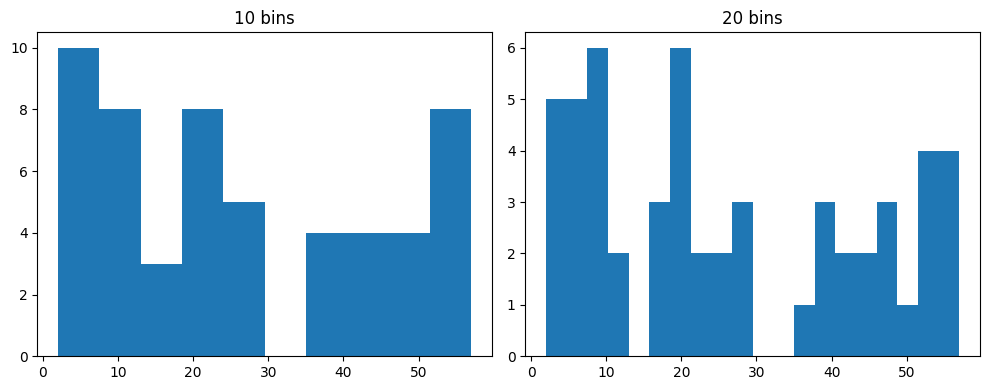

count    54.000000
mean     26.481481
std      18.381431
min       2.000000
25%       9.250000
50%      21.500000
75%      44.250000
max      57.000000
Name: iteration, dtype: float64


In [ ]:
##FILTER ON SELECTED RESPONSES
chosen_responses = merged[merged["chosen_response"] == True]

##PLOT CHOSEN_RESPONSE ITERATION HISTOGRAM - 10 AND 20 BINS
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ax1.hist(chosen_responses["iteration"], bins = 10)
ax1.title.set_text("10 bins")
ax2.hist(chosen_responses["iteration"], bins = 20)

plt.tight_layout()
ax2.title.set_text("20 bins")
plt.show()

print(chosen_responses["iteration"].describe())

### Examine variance in low iteration selections.

---

A starting variance of about 20 looks like it might capture immediate consensus while allowing for prompt improvement.

(array([3., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6., 1.,
        0., 0., 2.]),
 array([ 0.  ,  3.75,  7.5 , 11.25, 15.  , 18.75, 22.5 , 26.25, 30.  ,
        33.75, 37.5 , 41.25, 45.  , 48.75, 52.5 , 56.25, 60.  , 63.75,
        67.5 , 71.25, 75.  ]),
 <BarContainer object of 20 artists>)

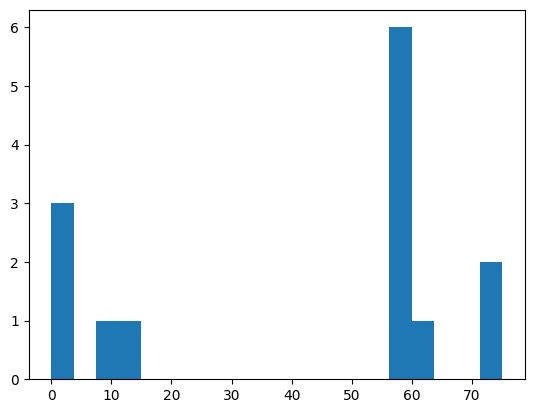

In [ ]:
low_iteration_responses = chosen_responses[chosen_responses["iteration"] < 10]

##HISTOGRAM OF VARIANCE AMONG LOW ITERATION RESPONSES
plt.hist(low_iteration_responses["score_moving_variance"], bins = 20)

### Examine accuracy by iteration

/tmp/ipython-input-947/2826559469.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy = pd.DataFrame(chosen_responses["correct"].groupby(chosen_responses["iter_bins"]).mean())


,correct
iter_bins,
"(1.999, 3.533]",0.500000
"(3.533, 6.067]",0.250000
"(6.067, 8.0]",0.750000
"(8.0, 10.0]",0.250000
"(10.0, 14.667]",0.000000
"(14.667, 19.2]",1.000000
"(19.2, 20.733]",0.666667
"(20.733, 23.267]",0.750000
"(23.267, 27.8]",0.333333


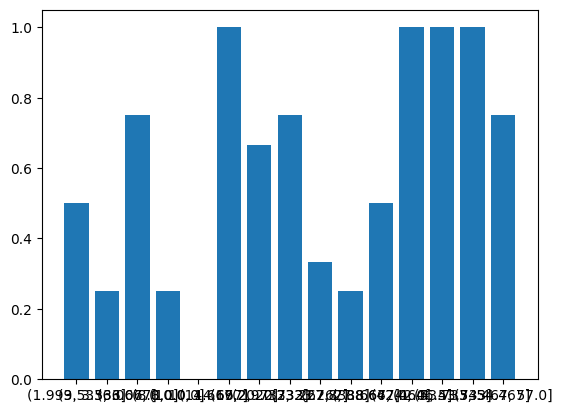

In [ ]:
##CALCULATE ACCURACY OF CHOSEN RESPONSES
chosen_responses = chosen_responses.copy()

chosen_responses["correct"] = chosen_responses["answer"] == chosen_responses["selected_choice"]

##CALCULATE RATIO OF CORRECT RESPONSES TO TOTAL RESPONSES BY ITERATION BIN - EVERY 15
chosen_responses["iter_bins"] = pd.qcut(chosen_responses['iteration'], q=15, duplicates = 'drop')
accuracy = pd.DataFrame(chosen_responses["correct"].groupby(chosen_responses["iter_bins"]).mean())
display(accuracy)
plt.bar([str(x) for x in accuracy.index.to_list()], accuracy["correct"])
plt.show()


### Accuracy by iteration without "Error" responses

/tmp/ipython-input-947/1899925906.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_error_chosen_responses["iter_bins"] = pd.qcut(non_error_chosen_responses['iteration'], q=15, duplicates = 'drop')
/tmp/ipython-input-947/1899925906.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ne_accuracy = pd.DataFrame(non_error_chosen_responses["correct"].groupby(non_error_chosen_responses["iter_bins"]).mean())


,correct
iter_bins,
"(1.999, 3.267]",0.500000
"(3.267, 6.067]",0.333333
"(6.067, 8.8]",1.000000
"(8.8, 12.267]",0.250000
"(12.267, 18.333]",1.000000
"(18.333, 20.0]",0.750000
"(20.0, 21.867]",0.500000
"(21.867, 25.267]",0.750000
"(25.267, 32.2]",0.000000


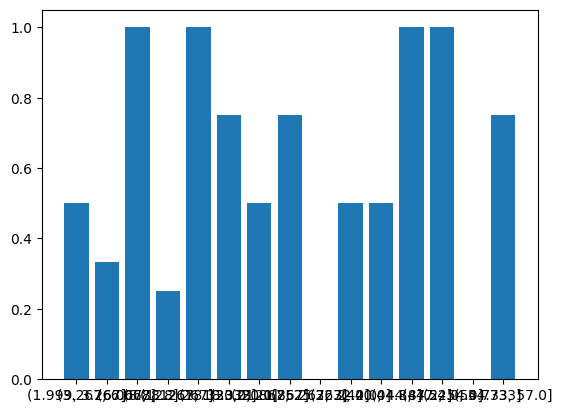

In [ ]:
non_error_chosen_responses = chosen_responses[chosen_responses["updated_answer"] != "Error"]

##CALCULATE RATIO OF CORRECT RESPONSES TO TOTAL RESPONSES BY ITERATION BIN - EVERY 15
non_error_chosen_responses["iter_bins"] = pd.qcut(non_error_chosen_responses['iteration'], q=15, duplicates = 'drop')
ne_accuracy = pd.DataFrame(non_error_chosen_responses["correct"].groupby(non_error_chosen_responses["iter_bins"]).mean())
display(ne_accuracy)
plt.bar([str(x) for x in ne_accuracy.index.to_list()], ne_accuracy["correct"])
plt.show()

### Selected choice location in total iteration count

,iteration
id,
550,23
605,2
737,14
755,39
780,38
944,64
967,46
1173,63
1185,16


(array([8., 2., 1., 3., 3., 2., 3., 3., 2., 1., 6., 1., 2., 6., 1., 3., 4.,
        2., 0., 1.]),
 array([ 1.  ,  4.65,  8.3 , 11.95, 15.6 , 19.25, 22.9 , 26.55, 30.2 ,
        33.85, 37.5 , 41.15, 44.8 , 48.45, 52.1 , 55.75, 59.4 , 63.05,
        66.7 , 70.35, 74.  ]),
 <BarContainer object of 20 artists>)

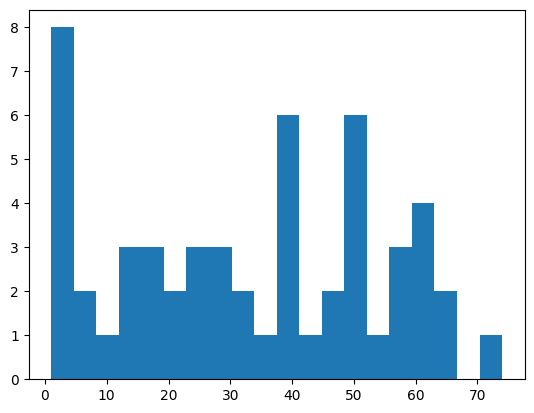

In [ ]:
##HOW MANY EXTRA ROUNDS WERE EXECUTED FOR ON AVERAGE - # ITERATIONS AT TRUE OVER MAX ITERATIONS PER QUESTION ID
max_iterations = pd.DataFrame(merged.groupby("id")["iteration"].max())
true_iterations = pd.DataFrame(merged[merged["chosen_response"] == True].groupby("id")["iteration"].max())

overshoot = pd.DataFrame(max_iterations["iteration"] - true_iterations["iteration"])
display(overshoot)

plt.hist(overshoot, bins = 20)


### Accuracy of high overshoot cases (that are not missing)

In [ ]:
##FILTER CHOSEN RESPONSES BASED ON QUESTION ID OF ITEMS WITH OVERSHOOT > 5
#print(overshoot.index[overshoot["iteration"] > 5])
high_overshoot = chosen_responses[chosen_responses["id"].isin(overshoot.index[overshoot["iteration"] > 5])]
print(len(high_overshoot[high_overshoot["correct"] == True]) / len(high_overshoot))
#


0.6666666666666666


Accuracy of all cases

In [ ]:
print(len(chosen_responses[chosen_responses["correct"] == True]) / len(chosen_responses))

0.6111111111111112


Accuracy of low overshoot cases (that are not missing)

In [ ]:
low_overshoot = chosen_responses[chosen_responses["id"].isin(overshoot.index[overshoot["iteration"] <= 5])]
print(len(low_overshoot["correct"] == True) / len(low_overshoot))

1.0


## 6. Variance parameter optimization
A simple parameter grid will be created using for loops, and a range of variance threshold starting points and growth rates will be explored.  The optimization function will be minimization of the mean squared overshoot, with the squaring serving to penalize large overshoot values more severly than small overshoot values.  The optimization function will also be lower bound restricted.  Optimization parameters that would result in undershooting a selected answer, and thus not encountering that answer, will be dropped from contention.

Overshoot will be calculated by determining at what point each cycle would've exited under the modified variance parameters, and determining the number of extra iterations considered by the ensemble for that cycle.

In [ ]:
##VARIANCE PARAMETER FUNCTION
def VarianceParamOptimization(df):
  ##IDENTIFY CASES WHERE SELECTED RESPONSE WAS "ERROR"
  error_cases = df[(df["updated_answer"] == "Error") & (df["chosen_response"] == True)]
  ##DROP CASES WHERE ERROR WAS SELECTED AS FINAL ANSWER
  mask = df['id'].isin(error_cases["id"])
  ne_df = df[~mask]

  max_iterations = ne_df.groupby("id")["iteration"].max().max()

  var_threshold_start_list = [1.5, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10]
  var_scaling_factor_list = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.10, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5]

  # var_threshold_start_list = [2]
  # var_scaling_factor_list = [1.1]

  true_iter = pd.DataFrame(ne_df[ne_df["chosen_response"] == True].groupby("id")["iteration"].max())
  overshoot_results = pd.DataFrame(columns = ["threshold", "scaling_factor", "mean_squared_overshoot"])
  for threshold in var_threshold_start_list:
    for scaling_factor in var_scaling_factor_list:

      ##CALCULATE PROGRESSIVE VARIANCE THRESHOLDS FOR CURRENT SET OF PARAMETERS
      thresholds = []
      base_threshold = threshold
      for i in range(max_iterations + 1):
        if (i % 3) == 0 and i > 0:
          new_threshold = base_threshold * scaling_factor
          if new_threshold < 3333.34:
            base_threshold = base_threshold ** scaling_factor
          else:
            ##SET TO MAX POSSIBLE VARIANCE TO AVOID EXPLODING THRESHOLD VALUES
            base_threshold = 3333.34

        thresholds.append(base_threshold)

      ##APPLY MODIFIED VARIANCE THRESHOLDS TO VARIANCE DATA
      var_df = ne_df.copy()
      variance_levels = [thresholds[i] for i in var_df["iteration"]]
      var_df.loc[:, "modified_variance_threshold"] = variance_levels
      var_df.loc[:, "modified_variance_exit"] = var_df["modified_variance_threshold"] >= var_df["score_moving_variance"]

      max_iter = pd.DataFrame(var_df[var_df["modified_variance_exit"] == True].groupby("id")["iteration"].min())

      overshoot = pd.DataFrame(max_iter["iteration"] - true_iter["iteration"])
      #print(overshoot)

      neg_overshoot = overshoot[overshoot['iteration'] < 0]

      ##IF UNDERSHOT MORE THAN 15% OF RESPONSES, SKIP
      if len(neg_overshoot) > len(true_iter) * .15:
          print(f"Excessive selected response undershooting, skipping. Threshold: {threshold}, Scaling factor: {scaling_factor}")
      else:
          mean_sq_overshoot = (overshoot["iteration"] ** 2).mean()

          overshoot_results.loc[len(overshoot_results.index)] = [threshold, scaling_factor, mean_sq_overshoot]

  return(overshoot_results)

var_opt = VarianceParamOptimization(merged)

Excessive selected response undershooting, skipping. Threshold: 1.5, Scaling factor: 1.2
Excessive selected response undershooting, skipping. Threshold: 1.5, Scaling factor: 1.25
Excessive selected response undershooting, skipping. Threshold: 1.5, Scaling factor: 1.3
Excessive selected response undershooting, skipping. Threshold: 1.5, Scaling factor: 1.35
Excessive selected response undershooting, skipping. Threshold: 1.5, Scaling factor: 1.4
Excessive selected response undershooting, skipping. Threshold: 1.5, Scaling factor: 1.45
Excessive selected response undershooting, skipping. Threshold: 1.5, Scaling factor: 1.5
Excessive selected response undershooting, skipping. Threshold: 2, Scaling factor: 1.15
Excessive selected response undershooting, skipping. Threshold: 2, Scaling factor: 1.2
Excessive selected response undershooting, skipping. Threshold: 2, Scaling factor: 1.25
Excessive selected response undershooting, skipping. Threshold: 2, Scaling factor: 1.3
Excessive selected respo

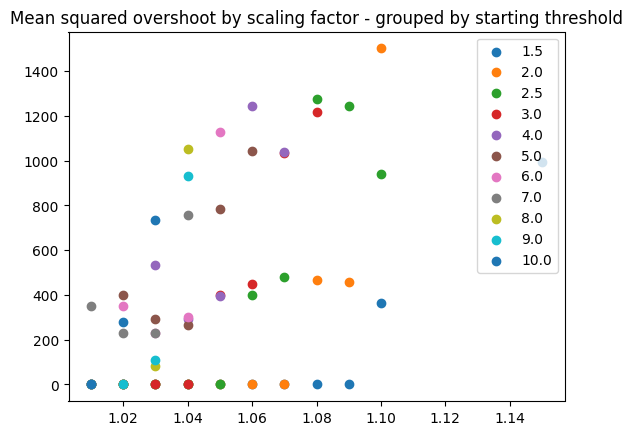

In [ ]:
fig, ax = plt.subplots()
for name, group_data in var_opt.groupby('threshold'):
    ax.scatter(group_data['scaling_factor'], group_data['mean_squared_overshoot'], label=name) #

ax.legend()
plt.title("Mean squared overshoot by scaling factor - grouped by starting threshold")
plt.show()

### Average variance at consensus

55.30246913580248
50.557863502352525


(array([14., 32.,  4.,  2.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([  0.        ,  30.83333333,  61.66666667,  92.5       ,
        123.33333333, 154.16666667, 185.        , 215.83333333,
        246.66666667, 277.5       , 308.33333333]),
 <BarContainer object of 10 artists>)

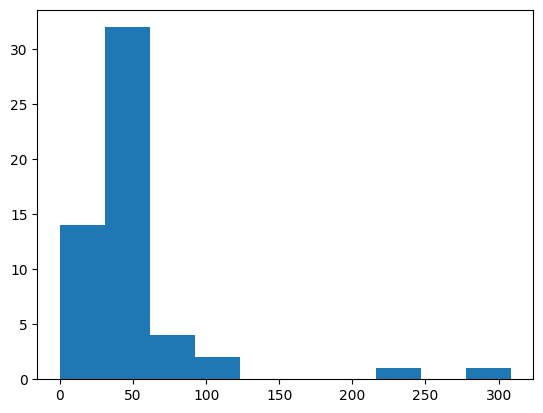

In [ ]:
avg_variance_at_consensus = merged[merged["chosen_response"] == True]["score_moving_variance"].mean()
avg_variance_std_at_consensus = merged[merged["chosen_response"] == True]["score_moving_variance"].std()
print(avg_variance_at_consensus)
print(avg_variance_std_at_consensus)

plt.hist(merged[merged["chosen_response"] == True]["score_moving_variance"])